# Charts — FIFA 17 Analysis

Depends on `fifa17_tratado.csv` generated by the `analise_fifa.ipynb` notebook. Run that notebook first.

## 1. Load cleaned data

In [13]:
# depends on fifa17_tratado.csv generated by the preparation notebook
import pandas as pd
from pathlib import Path

df = pd.read_csv(
    "fifa17_tratado.csv",
    parse_dates=["Birth_Date", "Club_Joining"],
)

# Recreate the boolean types lost in the CSV
for col in ["Convocado_Selecao", "Elite", "Contrato_Acabando"]:
    df[col] = df[col].astype(bool)

# Confirm everything came back correctly
print(df.shape)
print(df.dtypes[["Birth_Date", "Club_Joining", "Convocado_Selecao", "Elite", "Contrato_Acabando"]])

(17588, 63)
Birth_Date           datetime64[us]
Club_Joining         datetime64[us]
Convocado_Selecao              bool
Elite                          bool
Contrato_Acabando              bool
dtype: object


## 2. Average rating by age (full)

In [14]:
rating_by_age = df.groupby("Age")["Rating"].mean()
print(rating_by_age.round(1).to_string())

Age
17    55.5
18    56.8
19    58.6
20    60.7
21    63.0
22    64.4
23    65.5
24    67.0
25    67.8
26    68.4
27    68.8
28    69.3
29    69.5
30    69.5
31    70.0
32    69.9
33    69.2
34    69.2
35    69.4
36    69.3
37    69.0
38    66.5
39    68.8
40    67.8
41    64.0
42    64.0
43    60.3
44    67.3
47    45.0


## 3. Chart: average rating by age

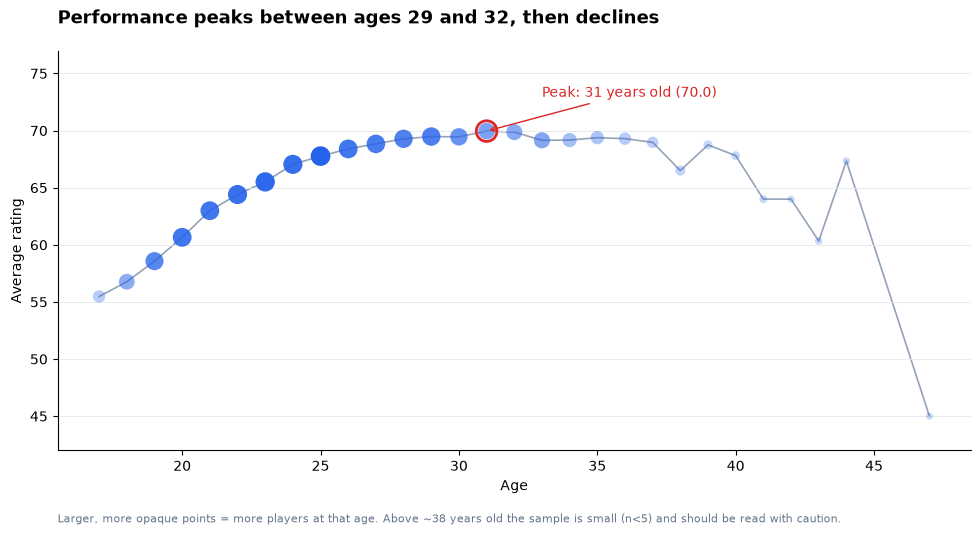

In [15]:
import matplotlib.pyplot as plt
import numpy as np

agg = df.groupby("Age")["Rating"].agg(["mean", "count"]).reset_index().sort_values("Age")

fig, ax = plt.subplots(figsize=(10, 5.5))

# background line connecting the points — thin and subdued
ax.plot(agg["Age"], agg["mean"], color="#94A3B8", linewidth=1.2, zorder=1)

# points sized and colored by number of players (sqrt, so area isn't distorted)
for _, row in agg.iterrows():
    weight = row["count"] / agg["count"].max()
    ax.scatter(row["Age"], row["mean"],
               s=20 + 180 * np.sqrt(weight),
               alpha=0.25 + 0.75 * weight,
               color="#2563EB", edgecolor="none", zorder=2)

# highlight the peak
peak = agg.loc[agg["mean"].idxmax()]
ax.scatter(peak["Age"], peak["mean"], s=220, facecolor="none",
           edgecolor="#DC2626", linewidth=2, zorder=3)
ax.annotate(f"Peak: {int(peak['Age'])} years old ({peak['mean']:.1f})",
            xy=(peak["Age"], peak["mean"]), xytext=(peak["Age"] + 2, peak["mean"] + 3),
            fontsize=10, color="#DC2626", arrowprops=dict(arrowstyle="->", color="#DC2626"))

ax.set_ylim(agg["mean"].min() - 3, agg["mean"].max() + 7)

ax.set_title("Performance peaks between ages 29 and 32, then declines",
             fontsize=13, fontweight="bold", loc="left", pad=20)
ax.set_xlabel("Age")
ax.set_ylabel("Average rating")
ax.text(0.0, -0.18,
        "Larger, more opaque points = more players at that age. "
        "Above ~38 years old the sample is small (n<5) and should be read with caution.",
        transform=ax.transAxes, fontsize=8, color="#64748B")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#E5E7EB", linewidth=0.6)

plt.tight_layout()
plt.savefig("age_rating_chart.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Chart: rating by nationality (top 10 countries)

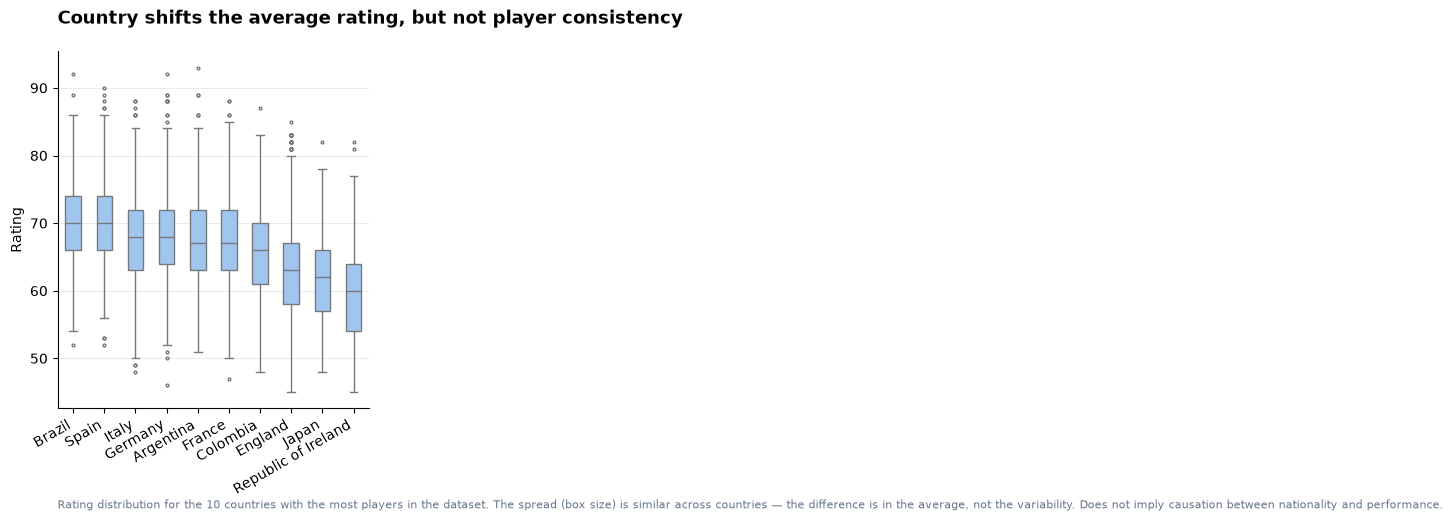

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = df["Nationality"].value_counts().head(10).index
df_top10 = df[df["Nationality"].isin(top10)]

order = (df_top10.groupby("Nationality")["Rating"].median()
         .sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(data=df_top10, x="Nationality", y="Rating", order=order,
            color="#93C5FD", width=0.5, fliersize=2, linewidth=1, ax=ax)

ax.set_title("Country shifts the average rating, but not player consistency",
             fontsize=13, fontweight="bold", loc="left", pad=20)
ax.set_xlabel("")
ax.set_ylabel("Rating")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#E5E7EB", linewidth=0.6)
plt.xticks(rotation=30, ha="right")

ax.text(0.0, -0.28,
        "Rating distribution for the 10 countries with the most players in the dataset. "
        "The spread (box size) is similar across countries — the difference "
        "is in the average, not the variability. Does not imply causation between "
        "nationality and performance.",
        transform=ax.transAxes, fontsize=8, color="#64748B")

plt.tight_layout()
plt.savefig("country_boxplot_chart.png", dpi=200, bbox_inches="tight")
plt.show()

In [17]:
df_top10.groupby("Nationality")["Rating"].agg(median="median", std_dev="std").loc[order].round(1)

,median,std_dev
Nationality,,
Brazil,70.0,5.6
Spain,70.0,6.1
Italy,68.0,7.2
Germany,68.0,7.3
Argentina,67.0,6.3
France,67.0,7.1
Colombia,66.0,6.4
England,63.0,7.2
Japan,62.0,6.3


## 5. Chart: clubs with the most elite players

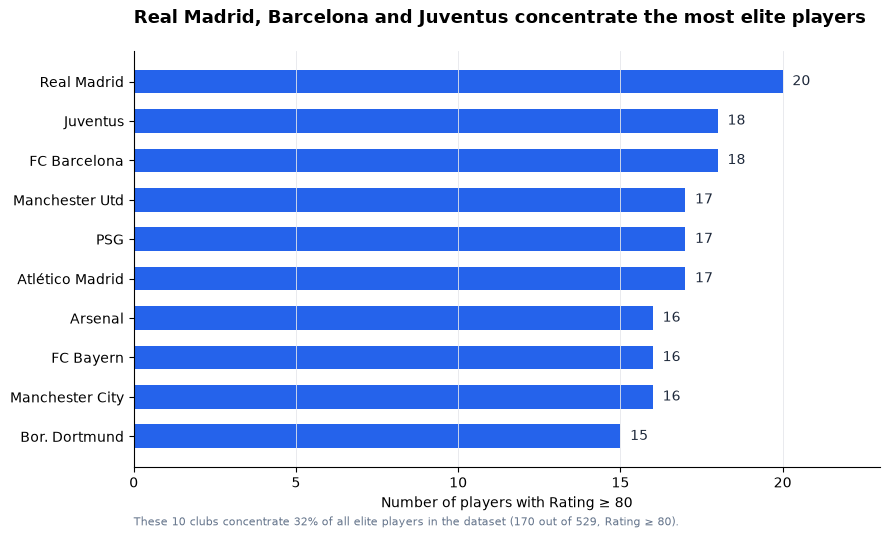

In [18]:
import matplotlib.pyplot as plt

elite_by_club = (
    df[df["Elite"] & (df["Club"] != "Free agent")]
    .groupby("Club").size()
    .sort_values(ascending=True)   # ascending so it plots bottom-up in barh
    .tail(10)
)

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(elite_by_club.index, elite_by_club.values, color="#2563EB", height=0.6)

# label at the end of each bar, instead of relying only on the axis
for bar, value in zip(bars, elite_by_club.values):
    ax.text(value + 0.3, bar.get_y() + bar.get_height() / 2, str(value),
            va="center", fontsize=10, color="#1E293B")

ax.set_title("Real Madrid, Barcelona and Juventus concentrate the most elite players",
             fontsize=13, fontweight="bold", loc="left", pad=20)
ax.set_xlabel("Number of players with Rating ≥ 80")
ax.set_ylabel("")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#E5E7EB", linewidth=0.6)
ax.set_xlim(0, max(elite_by_club.values) + 3)

ax.text(0.0, -0.14,
        "These 10 clubs concentrate 32% of all elite players in the "
        "dataset (170 out of 529, Rating ≥ 80).",
        transform=ax.transAxes, fontsize=8, color="#64748B")

plt.tight_layout()
plt.savefig("elite_clubs_chart.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Chart: expiring contract opportunities vs. age peak

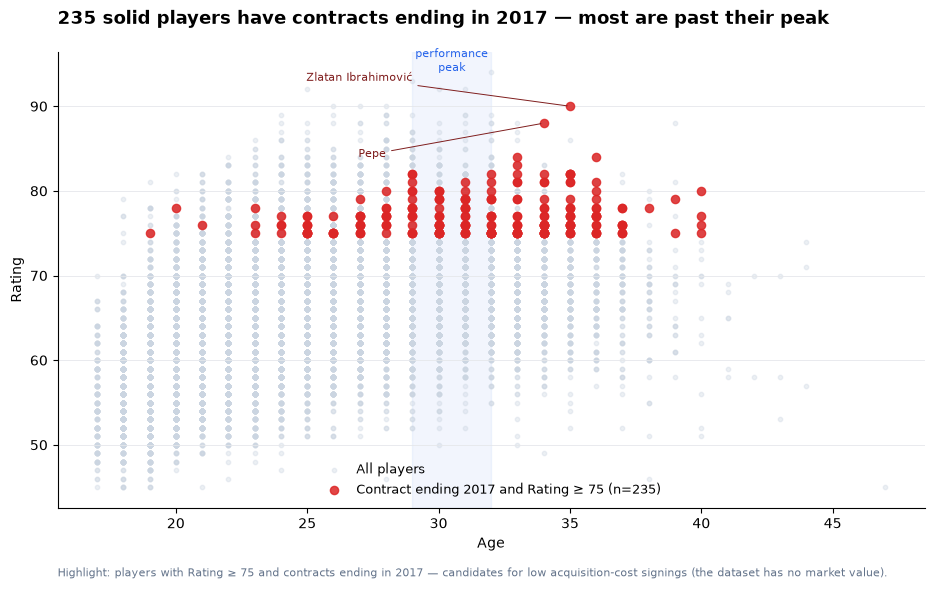

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# background: all players, light gray and subdued (context)
ax.scatter(df["Age"], df["Rating"], color="#CBD5E1", s=10, alpha=0.35, zorder=1,
           label="All players")

# highlight: opportunities (contract ending 2017 and Rating >= 75)
target = df[df["Contrato_Acabando"] & (df["Rating"] >= 75)]
ax.scatter(target["Age"], target["Rating"], color="#DC2626", s=35, alpha=0.85, zorder=2,
           label=f"Contract ending 2017 and Rating ≥ 75 (n={len(target)})")

# peak performance range (29-32 years old), tying back to the age chart
ax.axvspan(29, 32, color="#2563EB", alpha=0.06, zorder=0)
ax.text(30.5, 97, "performance\npeak", ha="center", va="top", fontsize=8, color="#2563EB")

# names of the top 2 standouts
for _, row in target.nlargest(2, "Rating").iterrows():
    if row["Name"] == "Zlatan Ibrahimović":
        xytext = (row["Age"] - 6, row["Rating"] + 3)
    else:  # Pepe
        xytext = (row["Age"] - 6, row["Rating"] - 4)
    ax.annotate(row["Name"], xy=(row["Age"], row["Rating"]), xytext=xytext,
                fontsize=8, color="#7F1D1D", ha="right",
                arrowprops=dict(arrowstyle="-", color="#7F1D1D", linewidth=0.7))

ax.set_title("235 solid players have contracts ending in 2017 — most are past their peak",
             fontsize=13, fontweight="bold", loc="left", pad=20)
ax.set_xlabel("Age")
ax.set_ylabel("Rating")
ax.legend(loc="lower center", frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#E5E7EB", linewidth=0.6)

ax.text(0.0, -0.15,
        "Highlight: players with Rating ≥ 75 and contracts ending in 2017 — "
        "candidates for low acquisition-cost signings (the dataset has no market value).",
        transform=ax.transAxes, fontsize=8, color="#64748B")

plt.tight_layout()
plt.savefig("contract_opportunities_chart.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Chart: heatmap of country x position

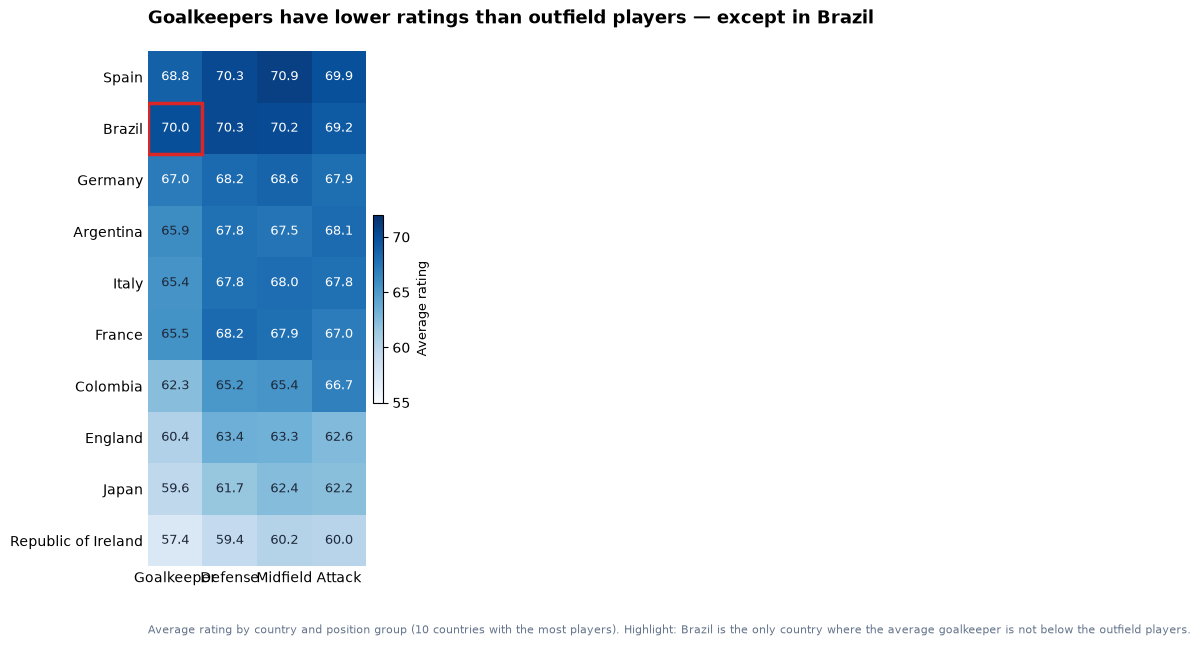

In [20]:
import matplotlib.pyplot as plt
import numpy as np

col_order = ["Goleiro", "Defesa", "Meio-campo", "Ataque"]
top10 = df["Nationality"].value_counts().head(10).index
sub = df[df["Nationality"].isin(top10)]

row_order = sub.groupby("Nationality")["Rating"].mean().sort_values(ascending=False).index
pivot = pd.pivot_table(sub, values="Rating", index="Nationality", columns="Grupo_Posicao",
                        aggfunc="mean")[col_order].loc[row_order]

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(pivot.values, cmap="Blues", aspect="auto", vmin=55, vmax=72)

ax.set_xticks(range(len(col_order)))
ax.set_xticklabels(["Goalkeeper", "Defense", "Midfield", "Attack"], rotation=0, ha="center")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

# value inside each cell, text color based on background
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        value = pivot.values[i, j]
        text_color = "white" if value > 66 else "#1E293B"
        ax.text(j, i, f"{value:.1f}", ha="center", va="center", fontsize=9, color=text_color)

# highlight the Brazil goalkeeper cell (the exception)
brazil_idx = list(pivot.index).index("Brazil")
ax.add_patch(plt.Rectangle((-0.5, brazil_idx - 0.5), 1, 1, fill=False,
                            edgecolor="#DC2626", linewidth=2.5))

ax.set_title("Goalkeepers have lower ratings than outfield players — except in Brazil",
             fontsize=13, fontweight="bold", loc="left", pad=20)

cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
cbar.set_label("Average rating", fontsize=9)

ax.spines[:].set_visible(False)
ax.tick_params(length=0)

ax.text(0.0, -0.13,
        "Average rating by country and position group (10 countries with the most players). "
        "Highlight: Brazil is the only country where the average goalkeeper is not "
        "below the outfield players.",
        transform=ax.transAxes, fontsize=8, color="#64748B")

plt.tight_layout()
fig.set_size_inches(9, 6.5)  # widen the figure to give the columns more room
plt.subplots_adjust(bottom=0.12)
plt.savefig("heatmap_country_position_chart.png", dpi=200, bbox_inches="tight")
plt.show()